<a href="https://colab.research.google.com/github/Alberto2804/ModelosIA/blob/main/datos_costes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Datos cargados y listos.
💸 ¡La IA ya ha aprendido a predecir las facturas médicas!
📊 Generando el gráfico explicativo...


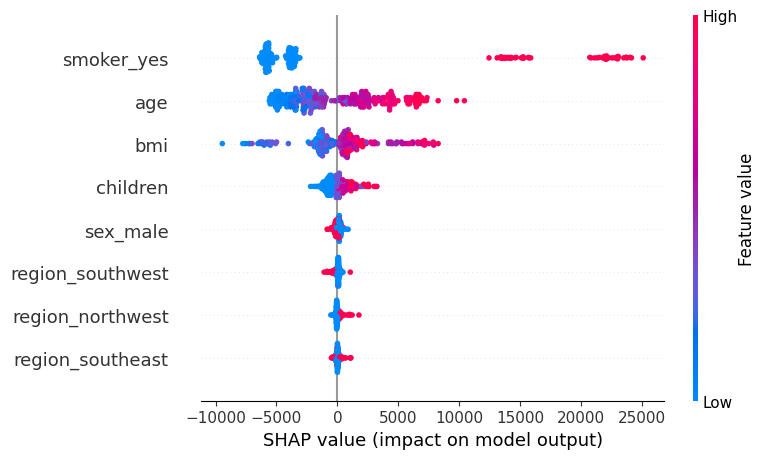

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap

# 1. Cargamos los datos del seguro médico
df_costes = pd.read_csv('datos_costes.csv')

# 2. Limpieza básica: convertimos texto (sexo, fumador, región) en números (0 y 1)
df_numerico = pd.get_dummies(df_costes, drop_first=True)

# 3. Separamos los datos
# La 'X' es el historial, la 'y' es la factura final ('charges')
X = df_numerico.drop('charges', axis=1)
y = df_numerico['charges']

# Guardamos el 20% para el examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Datos cargados y listos.")

# 4. Creamos y entrenamos el modelo (Ojo: ahora es un Regressor, no un Classifier)
modelo_regresion = RandomForestRegressor(random_state=42)
modelo_regresion.fit(X_train, y_train)
print("💸 ¡La IA ya ha aprendido a predecir las facturas médicas!")

# 5. Inteligencia Artificial Explicativa (XAI) con SHAP
print("📊 Generando el gráfico explicativo...")
explainer = shap.TreeExplainer(modelo_regresion)
shap_values = explainer.shap_values(X_test)

# 6. Dibujamos el gráfico para tu profesor
# Como es regresión, nos dibujará puntos de colores en lugar de barras
shap.summary_plot(shap_values, X_test)